**The goal :**

* We have seismic scans of underground rock with gaps between them, and we're building a ML model that fills in those gaps turning a bunch of separate 2D slices into one complete 3D picture of the underground.

**What that means :**

- You have 2D "slices" of underground rock (like X-ray scans), but they don't cover everything, there are gaps between them.
- We train a machine learning model: show it two known slices, it learns to predict the slice in between the known ones.
- Once trained, the model fills in ALL the gaps.
- Result: a full, continuous 3D block of the underground instead of scattered 2D slices.
- We save that 3D block as a file (SEGY format), that's the final deliverable.

So :

- Input: separate 2D files (Stratton2D_IL040, Stratton2D_IL060, ...) with gaps between them.

- Output: one 3D SEGY file with no gaps, a solid cube of underground data

## Step 1: Open one SEGY file and look at it

Number of traces (horizontal positions): 211
Number of samples per trace (depth axis): 1501
Shape of this seismic section: (211, 1501)


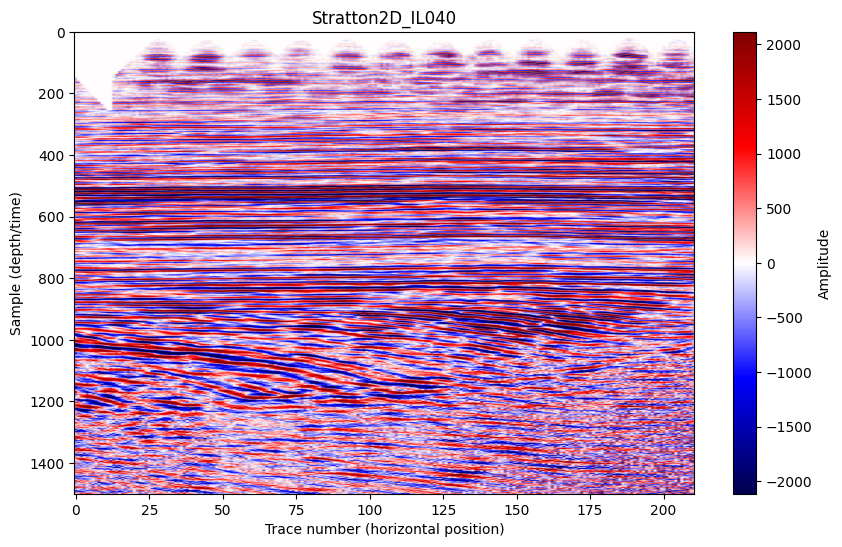

In [5]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

# Adjust this path to wherever your dataset folder is
filepath = "2D_Data/Stratton2D_IL040"

with segyio.open(filepath, "r", ignore_geometry=True) as f:
    f.mmap()
    n_traces = f.tracecount
    n_samples = len(f.samples)

    print(f"Number of traces (horizontal positions): {n_traces}")
    print(f"Number of samples per trace (depth axis): {n_samples}")

    data = np.zeros((n_traces, n_samples))
    for i in range(n_traces):
        data[i] = f.trace[i]

print("Shape of this seismic section:", data.shape)


plt.figure(figsize=(10, 6))
plt.imshow(data.T, cmap="seismic", aspect="auto",
           vmin=-np.percentile(np.abs(data), 95),
           vmax=np.percentile(np.abs(data), 95))
plt.xlabel("Trace number (horizontal position)")
plt.ylabel("Sample (depth/time)")
plt.title("Stratton2D_IL040")
plt.colorbar(label="Amplitude")
plt.show()

Explanation :


**What are the dataset files?**

Each file (Stratton2D_IL040, Stratton2D_XL220, Stratton2D_RL01, etc.) is one 2D cross-section slice through the underground, recorded at a specific survey line:

IL = Inline (one direction, e.g. running east-west)
XL = Crossline (perpendicular direction, e.g. running south-north)
RL = Random line (an arbitrary path, not aligned to the grid)
The number (040, 060, 220...) = the line's position/ID in the survey grid

So the dataset is a set of separate vertical "X-ray sheets" cut through the earth, spaced apart, and you're trying to fill in the sheets that are missing between them.


**X-axis: "Trace number (horizontal position)"**

Each trace = one recording location on the surface. At that spot, a sound source (vibrator truck or airgun) sent a shockwave down, and a receiver (geophone) recorded the echoes bouncing back off underground rock layers.

So trace 0, trace 1, trace 2... = physical positions along the survey line on the surface, spaced some fixed distance apart (say every 25m). Moving left to right on the X-axis = physically walking along the ground.


**Y-axis: "Sample (depth/time)"**

This is two-way travel time, how long (in milliseconds) it took the sound wave to go down, bounce off a rock boundary, and come back up. It's not literally meters of depth, but it acts like depth: shallow layers = small sample number (near top), deep layers = large sample number (near bottom). Roughly, more time = more depth (assuming consistent rock speed).


**Amplitude (the color grading bar)**

is How strong the reflected echo was at that point.

A rock boundary where properties change sharply (e.g. sandstone -> shale) reflects sound strongly -> big amplitude (dark red or dark blue)
No real boundary, or a gradual change → weak or near-zero amplitude (white/pale)
Red vs blue = the polarity of the reflection (whether the wave flipped or not when it bounced), this tells geologists whether density is increasing or decreasing at that boundary

In one sentence: each pixel says "at this surface location (X) and this travel-time depth (Y), how strongly did sound bounce back (amplitude/color), which tells you where rock layer boundaries are."

## Step 2: Load all files, extract line numbers, map the spacing pattern

**Goal :**

- We will load files then extract the number of each file name then define the spacing pattern between files.

- Find out exactly which lines we Have and what numbers are MISSING between them, that's what defines the "gaps" the model needs to learn to fill.

In [9]:
import os # Load Python's built-in toolbox for talking to the file system (listing folders, checking paths, etc.)
import re # Load Python's toolbox for regular expressions

data_dir = "2D_Data" # Just storing the dataset folder name as a variable, so we don't retype it everywhere.

files = os.listdir(data_dir) # Asks the operating system: "give me the names of every file sitting inside this folder." Result is a plain list of strings, like ["Stratton2D_IL040", "Stratton2D_XL220", ...]
print("Total files found:" , {len(files)}) # len(files) counts how many items are in that list
print(files[:5])  # print the first 5 items of the list

Total files found: {43}
['Stratton2D_IL040', 'Stratton2D_IL060', 'Stratton2D_IL080', 'Stratton2D_IL090', 'Stratton2D_IL120']


In [ ]:
# Parse line type (IL / XL / RL) and line number from each filename


pattern = re.compile(r"Stratton2D_(IL|XL|RL)(\d+)") # build a search pattern which is : find the text Stratton2D_, then either IL or XL or RL, then one or more digits.

lines_by_type = {"IL": [], "XL": [], "RL": []} # Creates an empty "bucket" for each line type, a dictionary where each key (IL, XL, RL) starts pointing to an empty list. We'll drop numbers into these buckets as we find them.

for fname in files: # Starts a loop: go through every filename in our files list, one at a time, calling the current one fname.
    
    match = pattern.search(fname) # Applies our pattern to this filename and checks: does it match? If yes, match holds the found pieces; if no, match is None.
    if match: # Only continue if we actually found a match
        line_type = match.group(1) # Pulls out the first captured group : the IL/XL/RL part.
        line_num = int(match.group(2)) # Pulls out the second captured group : the digits , and converts it from text ("040") into an actual number (40) using int().
        lines_by_type[line_type].append(line_num) # Drops this number into the correct bucket. E.g. if line_type is "IL", it adds line_num to lines_by_type["IL"].

for line_type, nums in lines_by_type.items():
    nums.sort()
    print(f"{line_type}: {len(nums)} lines -> {nums}")

IL: 14 lines -> [40, 60, 80, 90, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
XL: 12 lines -> [10, 30, 50, 70, 90, 110, 130, 150, 170, 190, 210, 220]
RL: 16 lines -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [11]:
for line_type, nums in lines_by_type.items():
    if len(nums) < 2:
        continue
    print(f"\n{line_type} spacing:")
    for i in range(len(nums) - 1):
        gap = nums[i+1] - nums[i]
        print(f"  {nums[i]} -> {nums[i+1]}  (gap = {gap})")


IL spacing:
  40 -> 60  (gap = 20)
  60 -> 80  (gap = 20)
  80 -> 90  (gap = 10)
  90 -> 120  (gap = 30)
  120 -> 140  (gap = 20)
  140 -> 160  (gap = 20)
  160 -> 180  (gap = 20)
  180 -> 200  (gap = 20)
  200 -> 220  (gap = 20)
  220 -> 240  (gap = 20)
  240 -> 260  (gap = 20)
  260 -> 280  (gap = 20)
  280 -> 300  (gap = 20)

XL spacing:
  10 -> 30  (gap = 20)
  30 -> 50  (gap = 20)
  50 -> 70  (gap = 20)
  70 -> 90  (gap = 20)
  90 -> 110  (gap = 20)
  110 -> 130  (gap = 20)
  130 -> 150  (gap = 20)
  150 -> 170  (gap = 20)
  170 -> 190  (gap = 20)
  190 -> 210  (gap = 20)
  210 -> 220  (gap = 10)

RL spacing:
  1 -> 2  (gap = 1)
  2 -> 3  (gap = 1)
  3 -> 4  (gap = 1)
  4 -> 5  (gap = 1)
  5 -> 6  (gap = 1)
  6 -> 7  (gap = 1)
  7 -> 8  (gap = 1)
  8 -> 9  (gap = 1)
  9 -> 10  (gap = 1)
  10 -> 11  (gap = 1)
  11 -> 12  (gap = 1)
  12 -> 13  (gap = 1)
  13 -> 14  (gap = 1)
  14 -> 15  (gap = 1)
  15 -> 16  (gap = 1)
